In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyampute.exploration.mcar_statistical_tests import MCARTest
from pygrinder import mcar_little_test
from missdat import mcar_test
import scipy.stats as stats
from phik import phik_matrix

In [6]:
# Loading the dataset
df = pd.read_csv('./data/student_data.csv')
print(df.head())
print(df.shape)

  First Term Gpa Second Term Gpa First Language  Funding  School  FastTrack  \
0              0               0              1        2       6          2   
1            2.5               2              3        4       6          1   
2           4.25        3.923077              1        1       6          2   
3       3.020833        2.321429              3        4       6          1   
4          4.275        4.326923              1        2       6          1   

   Coop  Residency  Gender Previous Education Age Group  \
0     1          1       2                  1         1   
1     2          2       2                  1         3   
2     1          1       1                  2         3   
3     2          2       2                  2         3   
4     1          1       1                  2         3   

  High School Average Mark Math Score English Grade  FirstYearPersistence  
0                       59         16             7                     1  
1                 

In [7]:
# Drop column 'School' since it has only one unique value
df.drop(columns=['School'], inplace=True)

In [8]:
# Checking how many missing data
df.replace('?', np.nan, inplace=True)
missing_counts = df.isnull().sum()
print(missing_counts)

df.columns = df.columns.astype(str)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.dtypes)

First Term Gpa               17
Second Term Gpa             160
First Language              111
Funding                       0
FastTrack                     0
Coop                          0
Residency                     0
Gender                        0
Previous Education            4
Age Group                     4
High School Average Mark    743
Math Score                  462
English Grade                45
FirstYearPersistence          0
dtype: int64
First Term Gpa              float64
Second Term Gpa             float64
First Language              float64
Funding                       int64
FastTrack                     int64
Coop                          int64
Residency                     int64
Gender                        int64
Previous Education          float64
Age Group                   float64
High School Average Mark    float64
Math Score                  float64
English Grade               float64
FirstYearPersistence          int64
dtype: object


In [9]:
missing_percentages = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage Missing (%)': missing_percentages.round(2) 
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
missing_summary = missing_summary.sort_values(by='Percentage Missing (%)', ascending=False)

print(missing_summary)

                          Missing Count  Percentage Missing (%)
High School Average Mark            743                   51.70
Math Score                          462                   32.15
Second Term Gpa                     160                   11.13
First Language                      111                    7.72
English Grade                        45                    3.13
First Term Gpa                       17                    1.18
Previous Education                    4                    0.28
Age Group                             4                    0.28


## Understanding what kind of missing data we have

In [10]:
# Using different libraries to perform the MCAR test
# 1. Using pyampute
# 2. Using pygrinder
# 3. Using missdat

In [11]:
mt = MCARTest(method='little')
pyampute_p_value = mt.little_mcar_test(df)
print(f'P-value from Little\'s MCAR test: {pyampute_p_value}')

if pyampute_p_value > 0.05:
    print("The data is Missing Completely at Random (MCAR).")
else:
    print("The data is not Missing Completely at Random (MCAR).")

P-value from Little's MCAR test: 0.0
The data is not Missing Completely at Random (MCAR).


In [12]:
pygrinder_p_value = mcar_little_test(df)
print(f'P-value from pygrinder Little\'s MCAR test: {pygrinder_p_value}')

P-value from pygrinder Little's MCAR test: 0.0


In [13]:
missdat_p_value = mcar_test(df)
print(f'P-value from missdat MCAR test: {missdat_p_value}')

P-value from missdat MCAR test:                                                     MCAR Test Values
number of missing patterns                                        27
x2                                                       2993.746276
df                                                            1587.0
p                                                                0.0
alpha                                                           0.05
interpretation              **Not** Random (Potentially MAR or MNAR)


In [1]:
# All data seemed to interpret the same result, which is that the data is not Missing Completely at Random (MCAR).
# Potentially, this means that the missingness of the data is related to the observed data.

In [21]:
# Trying to understand more using Anova
def anova_test(df, target_col, group_col):
    groups = df[group_col].dropna().unique()
    group_data = [df[df[group_col] == group][target_col].dropna() for group in groups]
    
    f_statistic, p_value = stats.f_oneway(*group_data)
    return f_statistic, p_value

for col in df.columns:
    if col != 'FirstYearPersistence':
        f_statistic, p_value = anova_test(df, 'FirstYearPersistence', col)
        print(f'ANOVA test for {col}: \nF-statistic={f_statistic:.4f}\np-value={p_value:.4f}')
        if p_value < 0.05:
            print(f"Result: Significant difference! '{col}' is a strong feature to predict 'First Term Gpa'.")
        else:
            print(f"Result: No significant difference. '{col}' might not help the neural network much.")

        print("=" * 50)

ANOVA test for First Term Gpa: 
F-statistic=2.2871
p-value=0.0000
Result: Significant difference! 'First Term Gpa' is a strong feature to predict 'First Term Gpa'.
ANOVA test for Second Term Gpa: 
F-statistic=1.2959
p-value=0.0006
Result: Significant difference! 'Second Term Gpa' is a strong feature to predict 'First Term Gpa'.
ANOVA test for First Language: 
F-statistic=24.9942
p-value=0.0000
Result: Significant difference! 'First Language' is a strong feature to predict 'First Term Gpa'.
ANOVA test for Funding: 
F-statistic=15.5581
p-value=0.0000
Result: Significant difference! 'Funding' is a strong feature to predict 'First Term Gpa'.
ANOVA test for FastTrack: 
F-statistic=48.5811
p-value=0.0000
Result: Significant difference! 'FastTrack' is a strong feature to predict 'First Term Gpa'.
ANOVA test for Coop: 
F-statistic=0.0149
p-value=0.9030
Result: No significant difference. 'Coop' might not help the neural network much.
ANOVA test for Residency: 
F-statistic=67.0079
p-value=0.0000

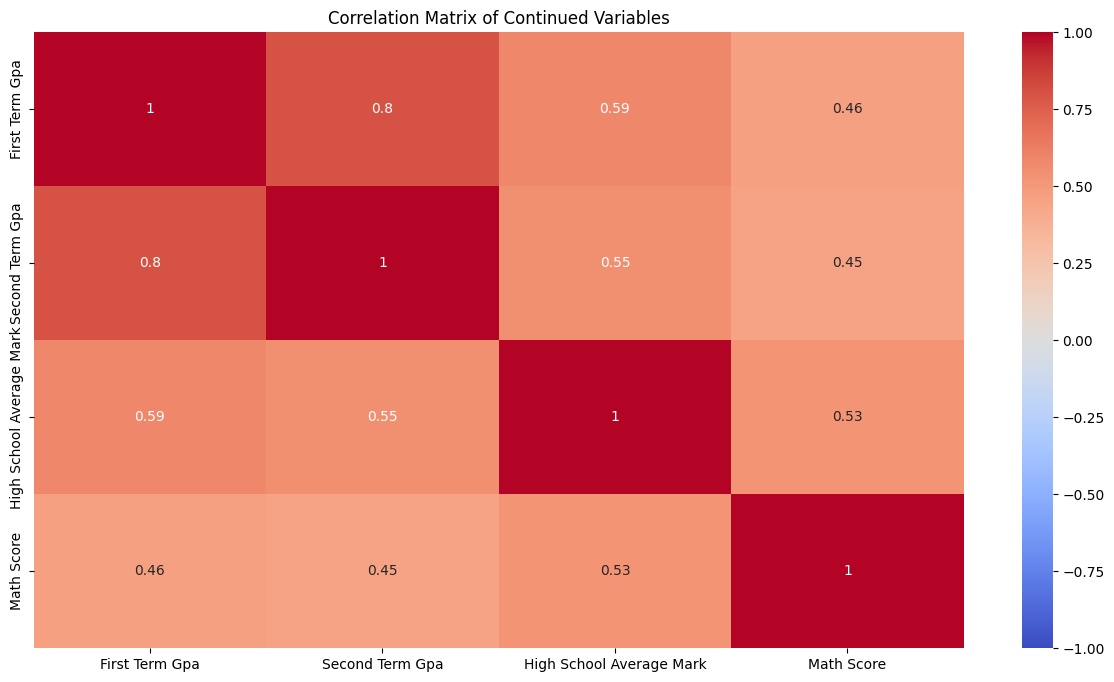

In [ ]:
# Correlation matrix for the continued variables
# Shows that there is a strong correlation between the first term GPA and the second term GPA, as well as between the high school average mark and the math score. 
filtered_df = df[['First Term Gpa', 'Second Term Gpa', 'High School Average Mark', 'Math Score']]
correlation_matrix = filtered_df.corr()
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Continued Variables')
plt.show()

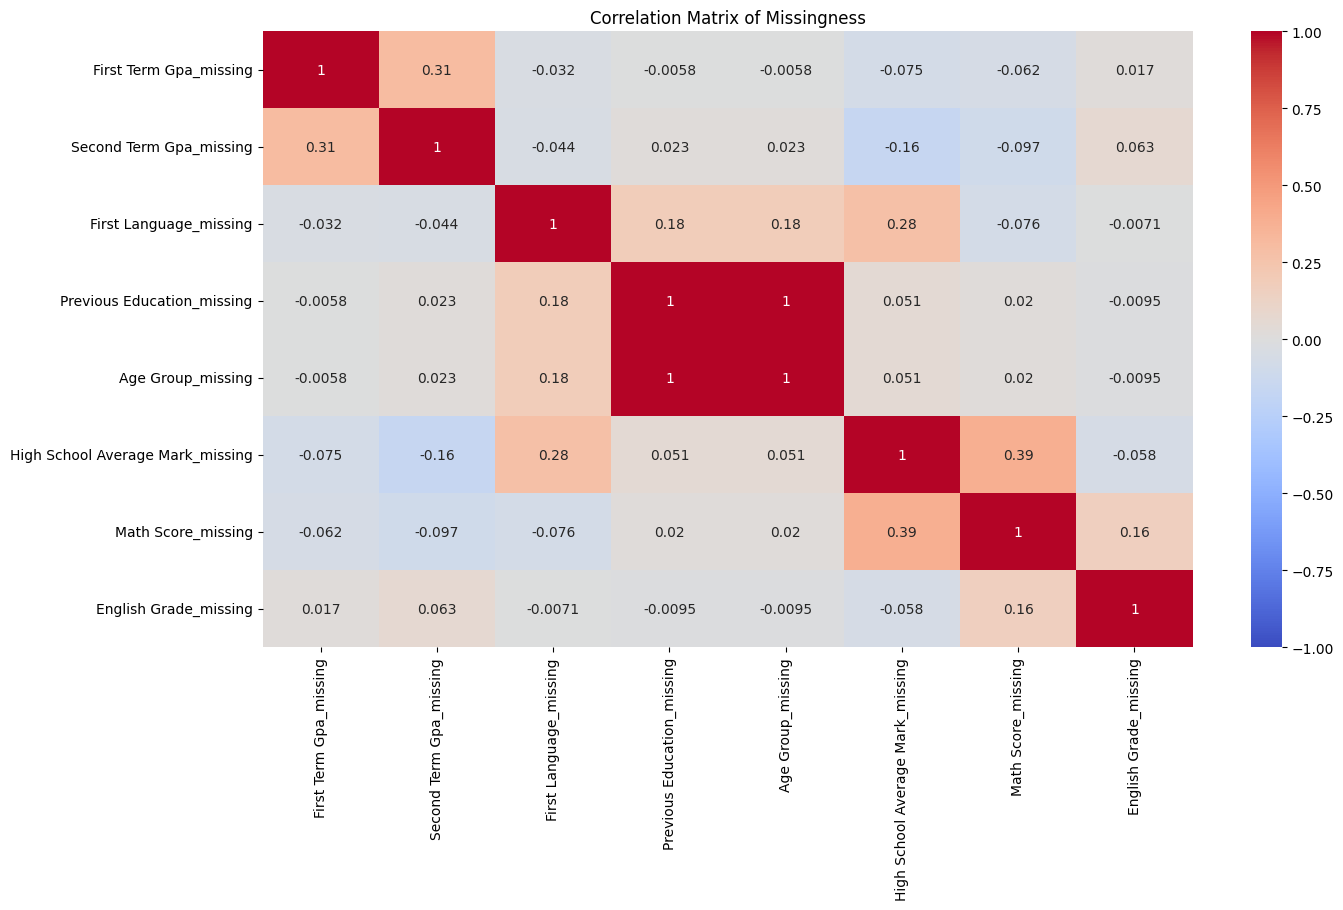

In [8]:
# Attempt to figure out if it is MAR or MNAR by checking the correlation between missingness and observed data
# Creating a shadow matrix to indicate missingness
shadow_matrix = df.isnull().astype(int)
shadow_matrix.columns = [f"{col}_missing" for col in shadow_matrix.columns]
cols_with_missing = shadow_matrix.columns[shadow_matrix.sum() > 0]
filtered_shadow_matrix = shadow_matrix[cols_with_missing]
correlation_matrix = filtered_shadow_matrix.corr()
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Missingness')
plt.show()

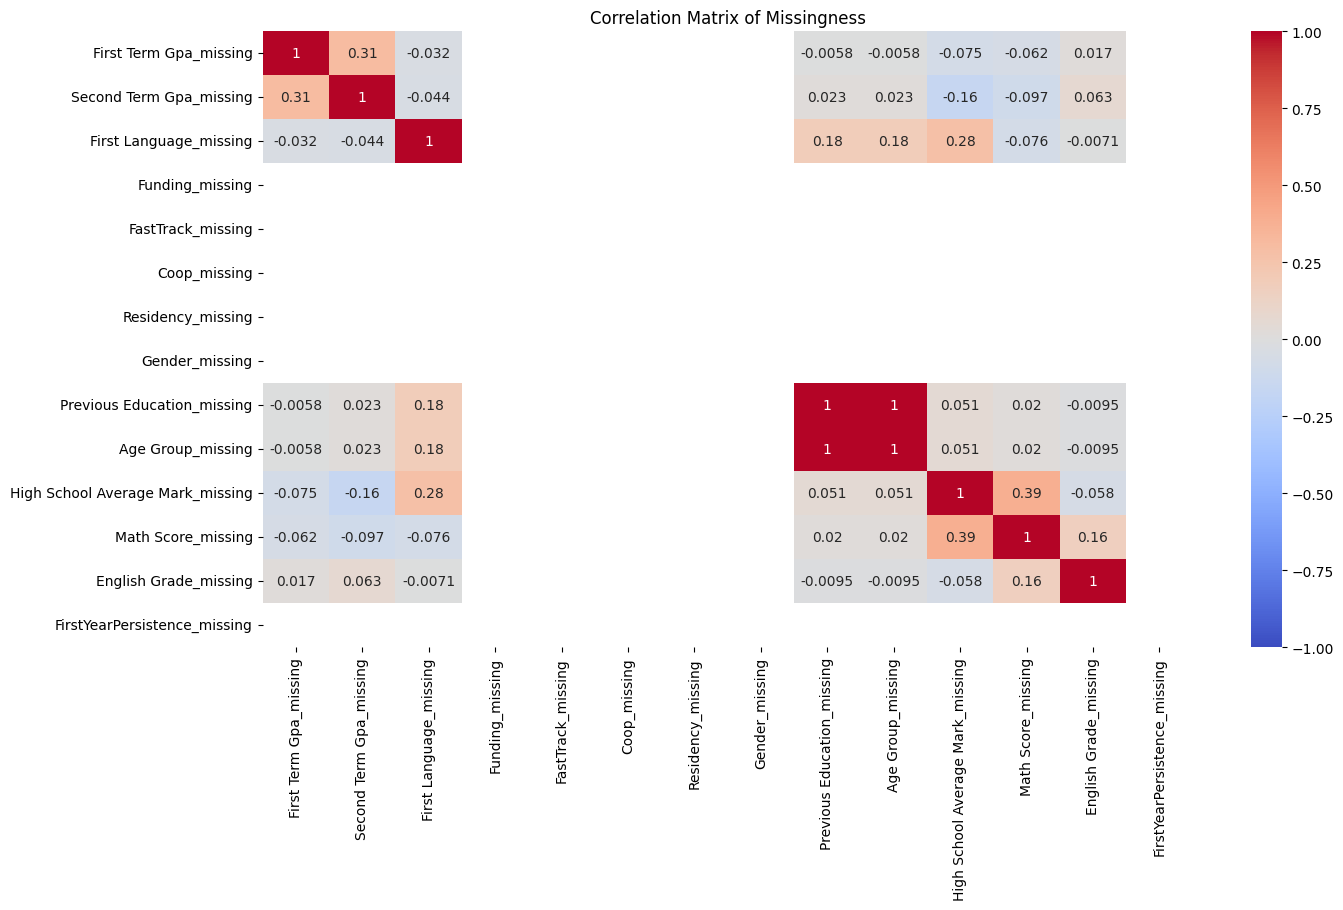

In [ ]:
# Full correlation matrix including all missingness indicators
correlation_matrix = shadow_matrix.corr()
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Missingness')
plt.show()

interval columns not set, guessing: ['First Term Gpa', 'Second Term Gpa', 'First Language', 'Funding', 'FastTrack', 'Coop', 'Residency', 'Gender', 'Previous Education', 'Age Group', 'High School Average Mark', 'Math Score', 'English Grade', 'FirstYearPersistence']
Phik Correlation with FirstYearPersistence:
FirstYearPersistence        1.000000
First Term Gpa              0.758170
Second Term Gpa             0.585994
Residency                   0.320760
Math Score                  0.315553
Funding                     0.305268
FastTrack                   0.274624
High School Average Mark    0.267188
English Grade               0.236573
Age Group                   0.196880
First Language              0.113000
Previous Education          0.074468
Gender                      0.048123
Coop                        0.000000
Name: FirstYearPersistence, dtype: float64


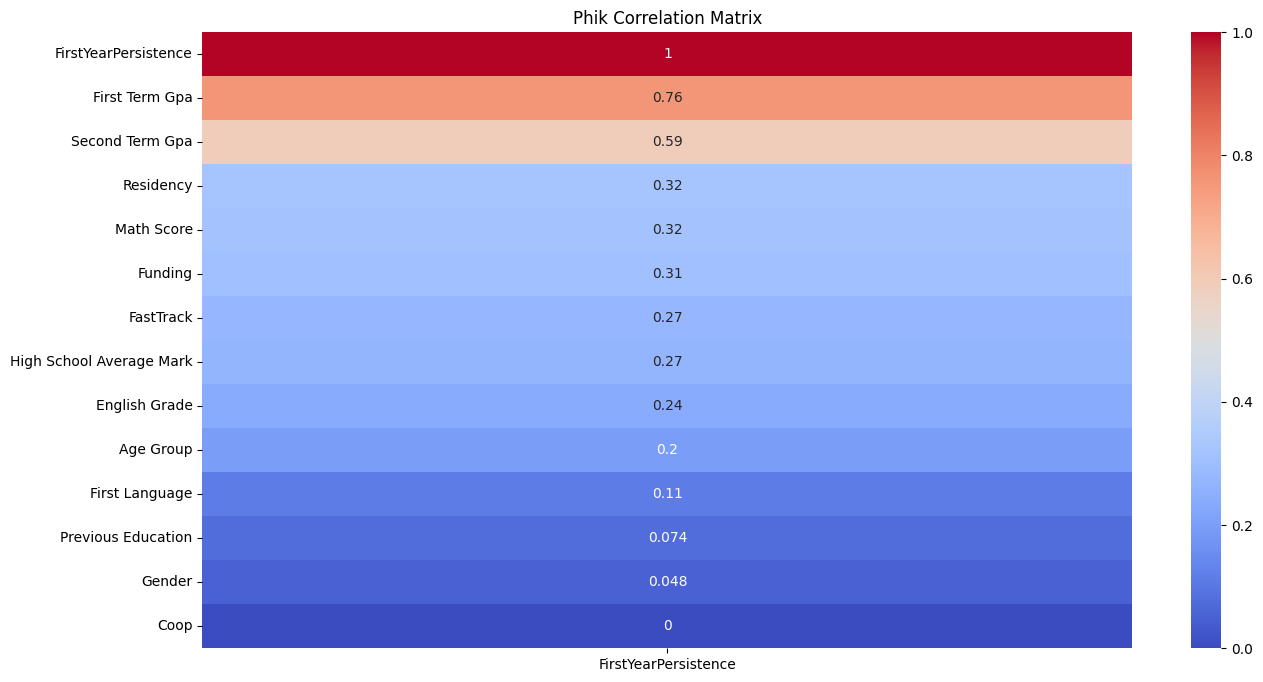

In [ ]:
# Phik correlation matrix to check the correlation between the missingness indicators and the target variable 'FirstYearPersistence'
# Using Phik correlation because it can handle mixed types of variables.
corr_matrix = phik_matrix(df)
persistence_corr = corr_matrix['FirstYearPersistence'].sort_values(ascending=False)
print("Phik Correlation with FirstYearPersistence:")
print(persistence_corr)

plt.figure(figsize=(15, 8))
sns.heatmap(persistence_corr.to_frame(), annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Phik Correlation Matrix')
plt.show()

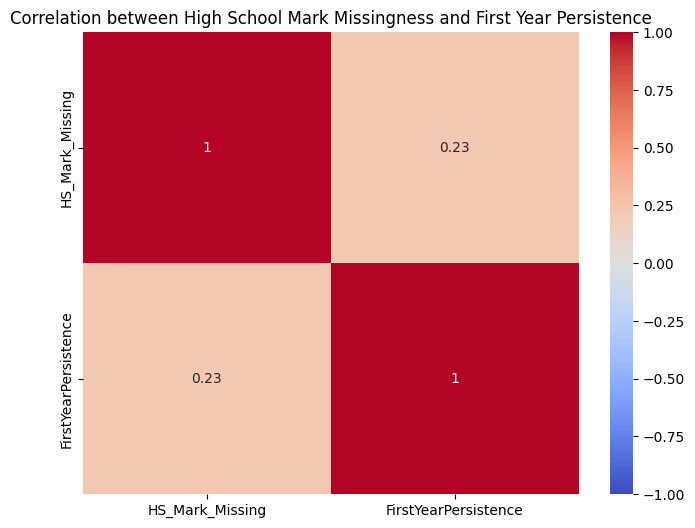

In [11]:
# Checking for missing patterns
df['HS_Mark_Missing'] = df['High School Average Mark'].isnull().astype(int)
subset_df = df[['HS_Mark_Missing', 'FirstYearPersistence']]
missing_pattern_corr = subset_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(missing_pattern_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between High School Mark Missingness and First Year Persistence')
plt.show()

interval columns not set, guessing: ['FirstYearPersistence', 'First Term Gpa', 'Second Term Gpa', 'High School Average Mark', 'HS_Missing', 'Math Score', 'Math_Missing', 'Age Group']


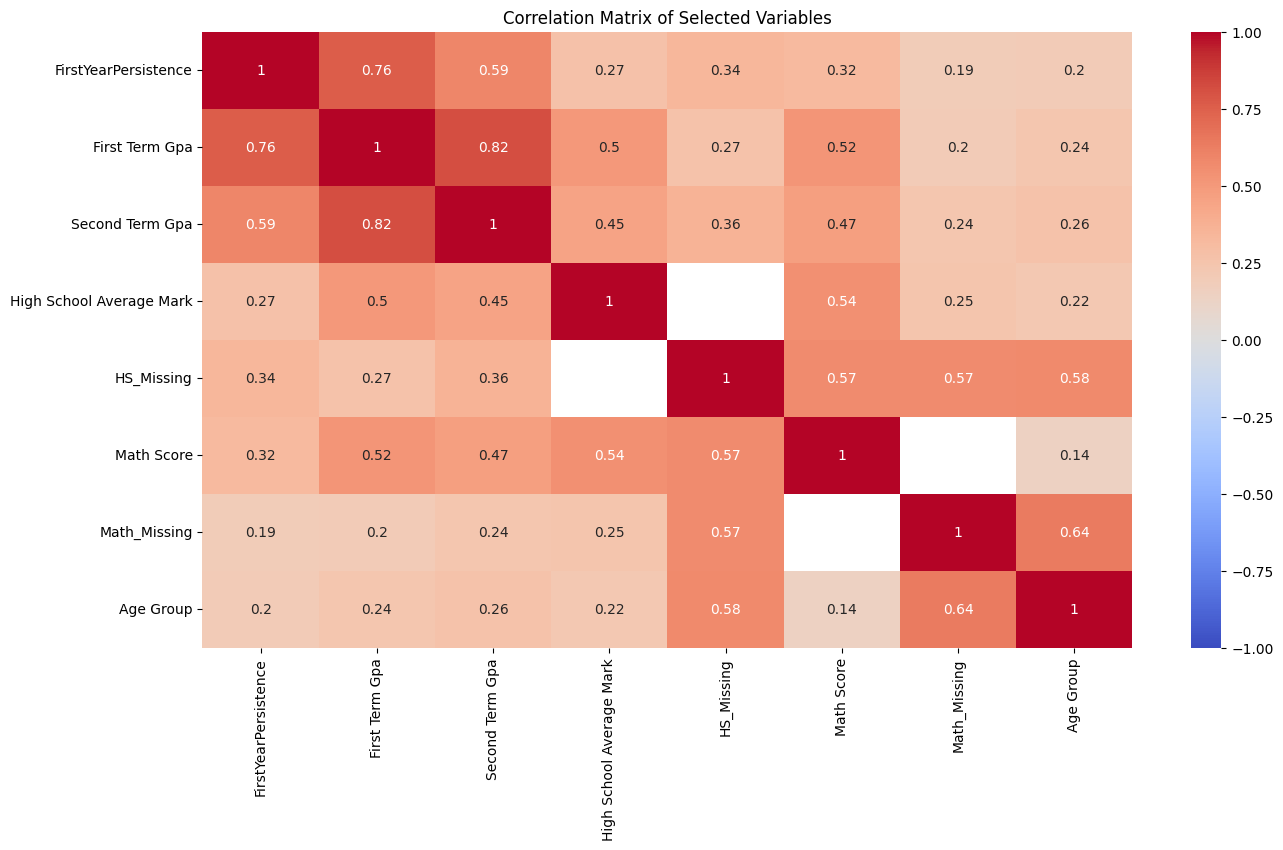

In [15]:
df['HS_Missing'] = df['High School Average Mark'].isna().astype(int)
df['Math_Missing'] = df['Math Score'].isna().astype(int)

columns_to_check = [
    'FirstYearPersistence', 
    'First Term Gpa', 
    'Second Term Gpa',
    'High School Average Mark', 
    'HS_Missing',
    'Math Score',
    'Math_Missing',
    'Age Group' # Adding Age Group just to prove our demographic theory!
]

subset_df = df[columns_to_check]
corr_matrix = phik_matrix(subset_df)
plt.figure(figsize=(15, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Selected Variables')
plt.show()

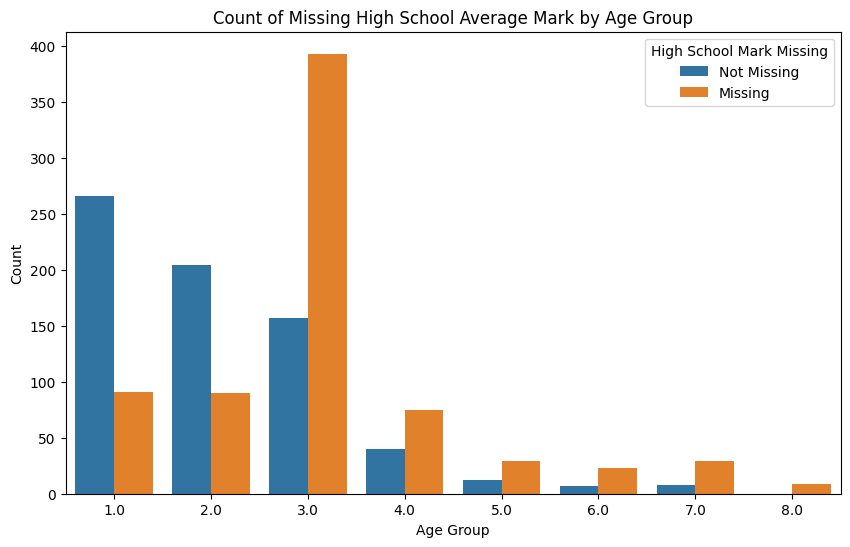

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age Group', hue='HS_Missing')
plt.title('Count of Missing High School Average Mark by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='High School Mark Missing', labels=['Not Missing', 'Missing'])
plt.show()

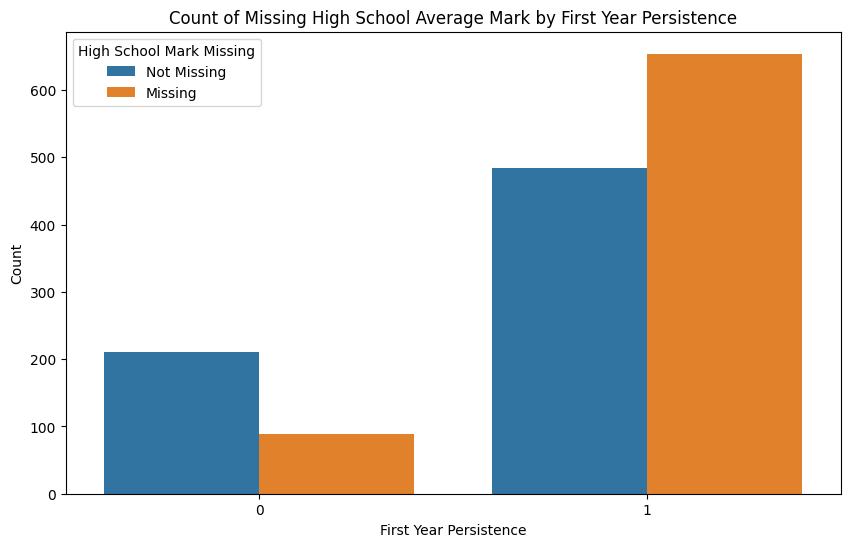

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='FirstYearPersistence', hue='HS_Missing')
plt.title('Count of Missing High School Average Mark by First Year Persistence')
plt.xlabel('First Year Persistence')
plt.ylabel('Count')
plt.legend(title='High School Mark Missing', labels=['Not Missing', 'Missing'])
plt.show()